[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/MNPS_Job_Classification_Likelihood_Scorer_PRODUCTION.ipynb)

# MNPS Job Classification Likelihood Scorer Llama_405b_v2

**AI-powered evaluation of job classification accuracy with comprehensive analysis**

This notebook implements a production-grade scoring system for MNPS job classifications using:
- **Core Model**: Llama-3.1-70B-Instruct or similar (GPT-4-class reasoning)
- **Evaluation Metrics**: KSAC similarity, salary impact, time-to-correct estimates
- **Output**: Structured likelihood scores with detailed justification

## Required Files
- **Input Data**: Sample JDsx.csv, Job Classifications Batch.csv
- **Evaluation Resources**: MNPS KSACS.csv, MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv, salary_by_major_role_grouping.csv, Ground Truth Masterfile.csv, Time to correct an error in hours.csv

## 1. Installation & Setup

In [1]:
%%capture
# Core dependencies
!pip install --upgrade pip
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers>=4.38.0 accelerate>=0.27.0
!pip install bitsandbytes>=0.42.0  # For quantization
!pip install chromadb>=0.4.22 sentence-transformers>=2.3.0
!pip install pandas numpy seaborn matplotlib plotly scikit-learn
!pip install chardet>=5.0.0  # For CSV encoding detection
!pip install openpyxl  # For Excel file support

print("✓ All dependencies installed")

In [2]:
import os
import json
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    pipeline
)
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.9.0+cu126
CUDA Available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.2 GB


## 2. Configuration

In [14]:
# Model selection
MODEL_OPTIONS = {
    "405b": "meta-llama/Meta-Llama-3.1-405B-Instruct",
    "70b": "meta-llama/Meta-Llama-3.1-70B-Instruct",
    "8b": "meta-llama/Meta-Llama-3.1-8B-Instruct",
}

# Configuration
CONFIG = {
    # Model settings
    "model_name": MODEL_OPTIONS["70b"],
    "use_4bit": True,
    "max_context": 128000,

    # Batch processing
    "batch_size": 50,
    "max_tokens_per_case": 2000,

    # Vector DB
    "embedding_model": "BAAI/bge-m3",
    "top_k_references": 5,

    # Generation
    "temperature": 0.1,
    "max_new_tokens": 8192,

    # Paths - UPDATE THESE
    "input_jds_path": "Sample JDs.csv",
    "input_batch_path": "Job Classifications Batch.csv",
    "ksacs_path": "MNPS KSACs.csv", # Corrected to lowercase 's' to match actual file
    "role_groups_path": "MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv",
    "salary_path": "salary_by_major_role_grouping.csv",
    "ground_truth_path": "Ground Truth Masterfile.csv",
    "time_to_correct_path": "Time to correct an error in hours.csv",
    "output_dir": "./mnps_results"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("✓ Configuration loaded")

✓ Configuration loaded


## 3. File Upload & Loading

In [4]:
# Uncomment to upload files in Colab
from google.colab import files
import zipfile

print("Please upload the following files:")
print("1. Sample JDsx.csv")
print("2. Job Classifications Batch.csv")
print("3. Evaluation Resources.zip (containing the 5 reference files)")
print()

uploaded = files.upload()

# Extract zip if uploaded
if 'Evaluation Resources.zip' in uploaded:
    with zipfile.ZipFile('Evaluation Resources.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("✓ Extracted evaluation resources")

print("\n✓ Files uploaded successfully")

Please upload the following files:
1. Sample JDsx.csv
2. Job Classifications Batch.csv
3. Evaluation Resources.zip (containing the 5 reference files)



Saving Evaluation Resources.zip to Evaluation Resources.zip
Saving Job Classifications Batch.csv to Job Classifications Batch.csv
Saving Sample JDs.csv to Sample JDs.csv
✓ Extracted evaluation resources

✓ Files uploaded successfully


In [5]:
import chardet
from io import StringIO
import csv

def detect_encoding(file_path: str) -> str:
    """Detect file encoding using chardet."""
    with open(file_path, 'rb') as f:
        raw_data = f.read(100000)
    result = chardet.detect(raw_data)
    encoding = result['encoding']
    confidence = result['confidence']
    print(f"  Detected encoding: {encoding} (confidence: {confidence:.2%})")
    return encoding if confidence > 0.7 else 'utf-8'

def detect_delimiter(file_path: str, encoding: str) -> str:
    """Detect CSV delimiter."""
    with open(file_path, 'r', encoding=encoding) as f:
        sample = f.read(4096)

    sniffer = csv.Sniffer()
    try:
        dialect = sniffer.sniff(sample)
        delimiter = dialect.delimiter
        print(f"  Detected delimiter: '{delimiter}'")
        return delimiter
    except:
        delimiters = [',', ';', '\t', '|']
        counts = {d: sample.count(d) for d in delimiters}
        delimiter = max(counts, key=counts.get)
        print(f"  Detected delimiter (fallback): '{delimiter}'")
        return delimiter

def load_csv_robust(file_path: str) -> pd.DataFrame:
    """Robustly load CSV with automatic encoding and delimiter detection."""
    print(f"\nLoading: {file_path}")
    print("=" * 60)

    encodings = [
        detect_encoding(file_path),
        'utf-8',
        'utf-8-sig',
        'latin1',
        'cp1252',
        'iso-8859-1',
        'ascii'
    ]

    df = None
    successful_encoding = None

    for encoding in encodings:
        try:
            print(f"\n  Trying: {encoding}")
            delimiter = detect_delimiter(file_path, encoding)

            df = pd.read_csv(
                file_path,
                encoding=encoding,
                delimiter=delimiter,
                on_bad_lines='skip',
                engine='python',
                quoting=csv.QUOTE_MINIMAL,
                escapechar='\\',
                skipinitialspace=True
            )

            if len(df) > 0 and len(df.columns) > 0:
                successful_encoding = encoding
                print(f"  ✓ Success with {encoding}")
                break

        except Exception as e:
            print(f"  ✗ Failed: {str(e)[:100]}")
            continue

    if df is None:
        raise ValueError(f"Could not load {file_path} with any encoding")

    # Clean column names
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')
    df = df.dropna(how='all')
    df = df.reset_index(drop=True)

    print("\n" + "=" * 60)
    print(f"✓ Loaded successfully!")
    print(f"  Rows: {len(df):,}")
    print(f"  Columns: {len(df.columns)}")
    print(f"  Column names: {df.columns.tolist()[:5]}{'...' if len(df.columns) > 5 else ''}")

    return df

print("✓ CSV loading functions ready")

✓ CSV loading functions ready


In [15]:
# Load all required files
print("Loading all data files...\n")

# Input data
df_jds = load_csv_robust(CONFIG['input_jds_path'])
df_batch = load_csv_robust(CONFIG['input_batch_path'])

# Evaluation resources
df_ksacs = load_csv_robust(CONFIG['ksacs_path'])
df_role_groups = load_csv_robust(CONFIG['role_groups_path'])
df_salary = load_csv_robust(CONFIG['salary_path'])
df_ground_truth = load_csv_robust(CONFIG['ground_truth_path'])
df_time_correct = load_csv_robust(CONFIG['time_to_correct_path'])

print("\n" + "=" * 60)
print("✓ All files loaded successfully!")
print("=" * 60)

Loading all data files...


Loading: Sample JDs.csv
  Detected encoding: Windows-1252 (confidence: 73.00%)

  Trying: Windows-1252
  Detected delimiter: ','
  ✓ Success with Windows-1252

✓ Loaded successfully!
  Rows: 61
  Columns: 8
  Column names: ['Job Code', 'Job Title', 'Position Summary', 'Education', 'Work Experience']...

Loading: Job Classifications Batch.csv
  Detected encoding: utf-8 (confidence: 87.62%)

  Trying: utf-8
  Detected delimiter: ','
  ✓ Success with utf-8

✓ Loaded successfully!
  Rows: 61
  Columns: 8
  Column names: ['source_row_index', 'job_title_original', 'new_job_title', 'major_role_group', 'minor_sub_group']...

Loading: MNPS KSACs.csv
  Detected encoding: ascii (confidence: 100.00%)

  Trying: ascii
  Detected delimiter: ','
  ✓ Success with ascii

✓ Loaded successfully!
  Rows: 315
  Columns: 5
  Column names: ['Role', 'Knowledge', 'Skills', 'Abilities', 'Competencies']

Loading: MNPS_Role_Groups_by_KSAC_Similarity_FINAL.csv
  Detected encoding: ascii

## 4. Data Preparation & Integration

In [16]:
# Merge job descriptions with classifications
# Adjust column names based on your actual data
print("Preparing evaluation dataset...\n")

# Display column names to help with merging
print("Job Descriptions columns:")
print(df_jds.columns.tolist())
print("\nBatch Classifications columns:")
print(df_batch.columns.tolist())
print()

# Merge based on common identifier (adjust column names as needed)
# Example: df_eval = df_jds.merge(df_batch, on='job_id', how='inner')
# For now, assuming the batch file has all necessary info
df_eval = df_batch.copy()

print(f"✓ Evaluation dataset prepared: {len(df_eval)} rows")
print(f"\nFirst row preview:")
df_eval.head(1)

Preparing evaluation dataset...

Job Descriptions columns:
['Job Code', 'Job Title', 'Position Summary', 'Education', 'Work Experience', 'Essential Functions', 'Licenses and Certifications', 'Knowledge, Skills and Abilities']

Batch Classifications columns:
['source_row_index', 'job_title_original', 'new_job_title', 'major_role_group', 'minor_sub_group', 'grouping_justification', 'model_used', 'reason_pass5']

✓ Evaluation dataset prepared: 61 rows

First row preview:


,source_row_index,job_title_original,new_job_title,major_role_group,minor_sub_group,grouping_justification,model_used,reason_pass5
0,0,Teacher Grade 8,Teacher,Teacher,NaN,The position's primary responsibilities involv...,gpt-4o-2024-11-20,NaN


In [23]:
# Create lookup dictionaries for fast access
print("Creating lookup dictionaries...\n")

# KSAC dictionary: role -> KSAC details
# Adjust column names based on your actual KSACS file
ksac_dict = {}
for _, row in df_ksacs.iterrows():
    role_raw = row.get('Role', row.get('role', None)) # Get raw value, use None for missing
    if pd.notna(role_raw) and str(role_raw).strip() != '': # Check if it's not NaN and not an empty string after conversion
        role = str(role_raw).strip()
        ksac_dict[role] = {
            'knowledge': row.get('Knowledge', ''),
            'skills': row.get('Skills', ''),
            'abilities': row.get('Abilities', ''),
            'competencies': row.get('Competencies', '')
        }

# Role groups dictionary
role_groups_dict = {}
for _, row in df_role_groups.iterrows():
    role_raw = row.get('Role', row.get('role', None))
    if pd.notna(role_raw) and str(role_raw).strip() != '':
        role = str(role_raw).strip()
        role_groups_dict[role] = {
            'group': row.get('Group', row.get('group', '')),
            'similar_roles': row.get('Similar_Roles', row.get('similar_roles', ''))
        }

# Salary dictionary
salary_dict = {}
for _, row in df_salary.iterrows():
    role_raw = row.get('Role', row.get('role', row.get('major_role_grouping', None)))
    if pd.notna(role_raw) and str(role_raw).strip() != '':
        role = str(role_raw).strip()
        salary_dict[role] = {
            'min': row.get('Min_Salary', row.get('min_salary', 0)),
            'max': row.get('Max_Salary', row.get('max_salary', 0)),
            'avg': row.get('Avg_Salary', row.get('avg_salary', 0))
        }

# Time to correct dictionary
time_correct_dict = {}
for _, row in df_time_correct.iterrows():
    error_type_raw = row.get('Error_Type', row.get('error_type', None))
    if pd.notna(error_type_raw) and str(error_type_raw).strip() != '':
        error_type = str(error_type_raw).strip()
        time_correct_dict[error_type] = row.get('Hours', row.get('hours', 0))

print(f"✓ KSAC dictionary: {len(ksac_dict)} roles")
print(f"✓ Role groups dictionary: {len(role_groups_dict)} roles")
print(f"✓ Salary dictionary: {len(salary_dict)} roles")
print(f"✓ Time to correct dictionary: {len(time_correct_dict)} error types")
print("\n✓ Lookup dictionaries created")

Creating lookup dictionaries...

✓ KSAC dictionary: 63 roles
✓ Role groups dictionary: 0 roles
✓ Salary dictionary: 0 roles
✓ Time to correct dictionary: 0 error types

✓ Lookup dictionaries created


## 5. Load Models

In [18]:
def load_llm(model_name: str, use_4bit: bool = True):
    """Load LLM with 4-bit quantization."""
    print(f"Loading {model_name}...")

    if use_4bit:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )

        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            device_map="auto",
            torch_dtype=torch.float16,
            trust_remote_code=True,
            use_cache=True
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            torch_dtype=torch.float16,
            trust_remote_code=True
        )

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token

    print(f"✓ Model loaded. Memory: {torch.cuda.memory_allocated() / 1e9:.1f} GB")
    return model, tokenizer

# Load main model
model, tokenizer = load_llm(CONFIG["model_name"], CONFIG["use_4bit"])

Loading meta-llama/Meta-Llama-3.1-70B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/59.6k [00:00<?, ?B/s]

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/183 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

✓ Model loaded. Memory: 39.5 GB


In [19]:
# Load embedding model for KSAC similarity calculations
print(f"Loading embedding model: {CONFIG['embedding_model']}...")
embedding_model = SentenceTransformer(CONFIG['embedding_model'])
print("✓ Embedding model loaded")

Loading embedding model: BAAI/bge-m3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✓ Embedding model loaded


## 6. Vector Database Setup

In [21]:
# Initialize ChromaDB for KSAC reference storage
import chromadb
from chromadb.utils import embedding_functions

# Use PersistentClient for modern ChromaDB persistence
chroma_client = chromadb.PersistentClient(path="./chroma_db")

collection = chroma_client.get_or_create_collection(
    name="mnps_ksacs",
    metadata={
        "description": "MNPS role KSAC definitions"
    },
    # embedding_function=embedding_functions.SentenceTransformerEmbeddingFunction(model_name=CONFIG['embedding_model'])
    # Note: Embedding function will be handled explicitly during add/query for flexibility
)

print("✓ ChromaDB initialized")

✓ ChromaDB initialized


In [24]:
def index_ksacs():
    """Index all KSAC definitions into vector DB."""
    print("Indexing KSAC definitions...")

    documents = []
    ids = []

    for role, ksac in ksac_dict.items():
        # Create rich text representation
        doc = f"""Role: {role}
Knowledge: {ksac['knowledge']}
Skills: {ksac['skills']}
Abilities: {ksac['abilities']}
Competencies: {ksac['competencies']}"""
        documents.append(doc)
        ids.append(f"role_{role.replace(' ', '_')}")

    # Generate embeddings
    embeddings = embedding_model.encode(documents, show_progress_bar=True)

    # Add to ChromaDB
    collection.add(
        documents=documents,
        embeddings=embeddings.tolist(),
        ids=ids
    )

    print(f"✓ Indexed {len(documents)} KSAC definitions")
    return len(documents)

num_indexed = index_ksacs()

Indexing KSAC definitions...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✓ Indexed 63 KSAC definitions


In [25]:
def retrieve_similar_roles(query: str, top_k: int = 5) -> List[str]:
    """Retrieve most similar role KSACs for a query."""
    query_embedding = embedding_model.encode([query])

    results = collection.query(
        query_embeddings=query_embedding.tolist(),
        n_results=top_k
    )

    return results['documents'][0] if results['documents'] else []

# Test retrieval
test_query = "Managing school transportation operations and safety"
similar_roles = retrieve_similar_roles(test_query, top_k=3)
print("\nTest retrieval for:", test_query)
print("\nTop 3 similar roles:")
for i, role in enumerate(similar_roles, 1):
    print(f"\n{i}. {role[:200]}...")


Test retrieval for: Managing school transportation operations and safety

Top 3 similar roles:

1. Role: Assistant Principal
Knowledge: School Operations and Procedures
Skills: Communication
Abilities: Adaptability
Competencies: Ensures Accountability; Action Oriented; Builds Effective Teams; Colla...

2. Role: Operator
Knowledge: Equipment Operation
Skills: Technical Skills
Abilities: Spatial Awareness
Competencies: Manages Complexity...

3. Role: Principal
Knowledge: Educational Leadership
Skills: Communication
Abilities: Adaptability
Competencies: Drives Vison and Purpose; 
Resourcefulness;
Action Oriented;
Develops Talent...


## 7. Evaluation Functions

In [28]:
def calculate_ksac_similarity(role1: str, role2: str) -> float:
    """Calculate KSAC similarity between two roles."""
    if role1 not in ksac_dict or role2 not in ksac_dict:
        return 0.0

    # Get KSAC texts
    ksac1 = ksac_dict[role1]
    ksac2 = ksac_dict[role2]

    # Combine all KSAC elements
    text1 = f"{ksac1['knowledge']} {ksac1['skills']} {ksac1['abilities']} {ksac1['competencies']}"
    text2 = f"{ksac2['knowledge']} {ksac2['skills']} {ksac2['abilities']} {ksac2['competencies']}"

    # Get embeddings
    emb1 = embedding_model.encode([text1])
    emb2 = embedding_model.encode([text2])

    # Calculate cosine similarity
    similarity = cosine_similarity(emb1, emb2)[0][0]
    return float(similarity)

# Test
# test_sim = calculate_ksac_similarity("Teacher", "Principal")
# print(f"KSAC Similarity: {test_sim:.3f}")

In [ ]:
def calculate_salary_impact(role1: str, role2: str) -> Dict:
    """Calculate salary impact of misclassification."""
    if role1 not in salary_dict or role2 not in salary_dict:
        return {'impact': 0, 'percentage': 0}

    sal1 = salary_dict[role1]['avg']
    sal2 = salary_dict[role2]['avg']

    impact = abs(sal1 - sal2)
    percentage = (impact / max(sal1, sal2) * 100) if max(sal1, sal2) > 0 else 0

    return {
        'impact': impact,
        'percentage': percentage,
        'role1_avg': sal1,
        'role2_avg': sal2
    }

# Test
# test_impact = calculate_salary_impact("Teacher", "Principal")
# print(f"Salary Impact: ${test_impact['impact']:,.0f} ({test_impact['percentage']:.1f}%)")

In [29]:
def estimate_time_to_correct(ksac_similarity: float, salary_impact: float) -> float:
    """Estimate time to correct based on error severity."""
    # Base time
    base_hours = 2.0

    # Adjust based on KSAC similarity (lower similarity = more time)
    ksac_factor = 1 + (1 - ksac_similarity)

    # Adjust based on salary impact
    if salary_impact > 20000:
        salary_factor = 2.0
    elif salary_impact > 10000:
        salary_factor = 1.5
    else:
        salary_factor = 1.0

    estimated_hours = base_hours * ksac_factor * salary_factor
    return estimated_hours

# Test
# test_time = estimate_time_to_correct(0.7, 15000)
# print(f"Estimated correction time: {test_time:.1f} hours")

## 8. Prompt Engineering

In [31]:
def build_evaluation_prompt(row: pd.Series, similar_roles: List[str]) -> str:
    """Build comprehensive evaluation prompt for a single classification."""

    # Extract job details (adjust column names as needed)
    job_title = row.get('job_title', row.get('Job_Title', 'Unknown'))
    job_description = row.get('job_description', row.get('Job_Description', ''))
    ai_classification = row.get('ai_role', row.get('AI_Role', ''))
    ai_justification = row.get('ai_justification', row.get('AI_Justification', ''))
    human_classification = row.get('human_role', row.get('Human_Role', ''))

    # Build context from similar roles
    similar_roles_text = "\n\n".join([f"### Reference Role {i+1}\n{role}" for i, role in enumerate(similar_roles)])

    prompt = f"""# JOB CLASSIFICATION LIKELIHOOD EVALUATION TASK

You are an expert HR analyst evaluating the accuracy of an AI job classification system for Metro Nashville Public Schools (MNPS).

## JOB INFORMATION
**Job Title**: {job_title}
**Job Description**: {job_description}

## AI CLASSIFICATION
**Assigned Role**: {ai_classification}
**AI Justification**: {ai_justification}

## HUMAN CLASSIFICATION (Ground Truth)
**Correct Role**: {human_classification}

## SIMILAR ROLES (for context)
{similar_roles_text}

## EVALUATION CRITERIA

Evaluate the AI classification on the following dimensions:

1. **Accuracy**: Is the AI classification correct?
2. **KSAC Alignment**: Do the Knowledge, Skills, Abilities, and Competencies match?
3. **Justification Quality**: Is the AI's reasoning sound and complete?
4. **Severity of Error** (if incorrect): How problematic is this misclassification?

## REQUIRED OUTPUT

Provide a JSON object with the following structure:

```json
{{
  "is_correct": true/false,
  "likelihood_score": 0-100,
  "confidence": "high"|"medium"|"low",
  "ksac_alignment_score": 0-100,
  "justification_quality_score": 0-100,
  "error_severity": "none"|"minor"|"moderate"|"severe",
  "reasoning": "detailed explanation (100-200 words)",
  "key_issues": ["issue 1", "issue 2", ...],
  "recommendations": "suggestions for improvement"
}}
```

**Scoring Guidelines**:
- **likelihood_score**: 90-100 (excellent), 75-89 (good), 60-74 (acceptable), <60 (problematic)
- **ksac_alignment_score**: How well the role matches required competencies
- **justification_quality_score**: Completeness and accuracy of AI reasoning

Respond ONLY with the JSON object, no additional text.
"""

    return prompt

print("✓ Prompt builder ready")

✓ Prompt builder ready


## 9. Batch Evaluation Pipeline

In [32]:
def generate_evaluation(prompt: str) -> str:
    """Generate evaluation using LLM."""
    messages = [
        {"role": "system", "content": "You are an expert HR analyst. Provide structured JSON responses."},
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=CONFIG['max_context']
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=CONFIG['max_new_tokens'],
            temperature=CONFIG['temperature'],
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "assistant" in generated_text:
        response = generated_text.split("assistant")[-1].strip()
    else:
        response = generated_text

    return response

print("✓ Generation function ready")

✓ Generation function ready


In [33]:
def parse_json_response(response: str) -> Dict:
    """Extract JSON from model response."""
    try:
        return json.loads(response)
    except:
        import re
        json_match = re.search(r'```(?:json)?\s*([\s\S]*?)```', response)
        if json_match:
            return json.loads(json_match.group(1))

        obj_match = re.search(r'\{[\s\S]*\}', response)
        if obj_match:
            return json.loads(obj_match.group(0))

        raise ValueError("Could not extract JSON from response")

print("✓ JSON parser ready")

✓ JSON parser ready


In [34]:
def process_all_classifications(df: pd.DataFrame) -> List[Dict]:
    """Process all job classifications and generate likelihood scores."""
    all_results = []
    total = len(df)

    print(f"Processing {total} classifications...\n")

    for idx, row in df.iterrows():
        print(f"\nProcessing {idx + 1}/{total}...")

        try:
            # Get job description for similarity search
            job_desc = row.get('job_description', row.get('Job_Description', ''))

            # Retrieve similar roles
            similar_roles = retrieve_similar_roles(job_desc, top_k=CONFIG['top_k_references'])

            # Build prompt
            prompt = build_evaluation_prompt(row, similar_roles)

            # Generate
            response = generate_evaluation(prompt)

            # Parse
            result = parse_json_response(response)

            # Add computed metrics
            ai_role = row.get('ai_role', row.get('AI_Role', ''))
            human_role = row.get('human_role', row.get('Human_Role', ''))

            result['ksac_similarity_computed'] = calculate_ksac_similarity(ai_role, human_role)
            salary_impact = calculate_salary_impact(ai_role, human_role)
            result['salary_impact'] = salary_impact['impact']
            result['salary_impact_pct'] = salary_impact['percentage']
            result['estimated_correction_hours'] = estimate_time_to_correct(
                result['ksac_similarity_computed'],
                salary_impact['impact']
            )

            result['row_id'] = idx
            all_results.append(result)

            print(f"  ✓ Score: {result.get('likelihood_score', 'N/A')}")

        except Exception as e:
            print(f"  ⚠ Error: {e}")
            all_results.append({
                "row_id": idx,
                "likelihood_score": None,
                "error": str(e)
            })

    return all_results

print("✓ Processing function ready")

✓ Processing function ready


In [36]:
# Run evaluation on full dataset (or subset for testing)
print("Starting full evaluation...\n")

# For testing, process first N rows
TEST_MODE = True
TEST_ROWS = 10

if TEST_MODE:
    print(f"TEST MODE: Processing first {TEST_ROWS} rows\n")
    results = process_all_classifications(df_eval.head(TEST_ROWS))
else:
    print(f"PRODUCTION MODE: Processing all {len(df_eval)} rows\n")
    results = process_all_classifications(df_eval)

print(f"\n✓ Evaluation complete: {len(results)} results")

Starting full evaluation...

TEST MODE: Processing first 10 rows

Processing 10 classifications...


Processing 1/10...
  ✓ Score: 30

Processing 2/10...
  ✓ Score: 40

Processing 3/10...
  ✓ Score: 30

Processing 4/10...
  ✓ Score: 30

Processing 5/10...
  ✓ Score: 40

Processing 6/10...
  ✓ Score: 30

Processing 7/10...
  ✓ Score: 30

Processing 8/10...
  ✓ Score: 30

Processing 9/10...
  ✓ Score: 30

Processing 10/10...
  ✓ Score: 40

✓ Evaluation complete: 10 results


## 10. Results Analysis & Visualization

In [37]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Merge with original data
df_final = df_eval.merge(
    results_df,
    left_index=True,
    right_on='row_id',
    how='left'
)

# Save detailed results
output_file = f"{CONFIG['output_dir']}/mnps_likelihood_scores_detailed.csv"
df_final.to_csv(output_file, index=False)
print(f"✓ Detailed results saved to {output_file}")

# Display summary
print("\n=== SUMMARY STATISTICS ===")
print(f"Total evaluations: {len(df_final)}")
print(f"\nLikelihood Scores:")
print(f"  Mean: {df_final['likelihood_score'].mean():.2f}")
print(f"  Median: {df_final['likelihood_score'].median():.2f}")
print(f"  Std Dev: {df_final['likelihood_score'].std():.2f}")
print(f"  Range: {df_final['likelihood_score'].min():.0f} - {df_final['likelihood_score'].max():.0f}")

print(f"\nAccuracy:")
if 'is_correct' in df_final.columns:
    accuracy = (df_final['is_correct'].sum() / len(df_final) * 100)
    print(f"  Correct classifications: {accuracy:.1f}%")

print(f"\nError Severity Distribution:")
if 'error_severity' in df_final.columns:
    print(df_final['error_severity'].value_counts())

print(f"\nAverage Metrics:")
print(f"  KSAC Alignment: {df_final['ksac_alignment_score'].mean():.2f}")
print(f"  Justification Quality: {df_final['justification_quality_score'].mean():.2f}")
print(f"  Salary Impact: ${df_final['salary_impact'].mean():,.0f}")
print(f"  Correction Time: {df_final['estimated_correction_hours'].mean():.1f} hours")

df_final.head()

✓ Detailed results saved to ./mnps_results/mnps_likelihood_scores_detailed.csv

=== SUMMARY STATISTICS ===
Total evaluations: 61

Likelihood Scores:
  Mean: 33.00
  Median: 30.00
  Std Dev: 4.83
  Range: 30 - 40

Accuracy:
  Correct classifications: 0.0%

Error Severity Distribution:
error_severity
moderate    6
severe      4
Name: count, dtype: int64

Average Metrics:
  KSAC Alignment: 21.00
  Justification Quality: 24.00
  Salary Impact: $0
  Correction Time: 4.0 hours


,source_row_index,job_title_original,new_job_title,major_role_group,minor_sub_group,grouping_justification,model_used,reason_pass5,is_correct,likelihood_score,...,justification_quality_score,error_severity,reasoning,key_issues,recommendations,ksac_similarity_computed,salary_impact,salary_impact_pct,estimated_correction_hours,row_id
0.0,0,Teacher Grade 8,Teacher,Teacher,NaN,The position's primary responsibilities involv...,gpt-4o-2024-11-20,NaN,False,30.0,...,40.0,moderate,The AI classification failed to provide any in...,"[Lack of AI classification details, Insufficie...",Provide more detailed AI classification output...,0.0,0.0,0.0,4.0,0
1.0,1,Mgr Data Quality and Integrity,Data Manager II,Manager,II,The position should remain classified as 'Mana...,gpt-4o-2024-11-20,"The role involves supervising staff, evaluatin...",False,40.0,...,30.0,moderate,The AI classification failed to provide any in...,"[Missing job description, Lack of AI-assigned ...",Provide a detailed job description and ensure ...,0.0,0.0,0.0,4.0,1
2.0,2,Coord Evaluation RAE,Evaluation Analyst III,Analyst,III,The position involves advanced responsibilitie...,gpt-4o-2024-11-20,NaN,False,30.0,...,10.0,severe,The AI classification failed to provide any in...,[No assigned role was provided by the AI syste...,It is essential to retrain the AI model using ...,0.0,0.0,0.0,4.0,2
3.0,3,Dir Assessment RAE,Director of Assessment,Director,NaN,The position clearly demonstrates Director-lev...,gpt-4o-2024-11-20,NaN,False,30.0,...,10.0,severe,The AI classification failed to provide any in...,"[No assigned role provided by the AI, Insuffic...",It is essential to re-evaluate the AI system's...,0.0,0.0,0.0,4.0,3
4.0,4,Analyst Data Operations RAE,Data Analyst II,Analyst,II,The job description focuses on tasks such as o...,gpt-4o-2024-11-20,NaN,False,40.0,...,30.0,moderate,The AI classification failed to provide any in...,"[Lack of AI classification details, Insufficie...",Provide more detailed AI classification result...,0.0,0.0,0.0,4.0,4


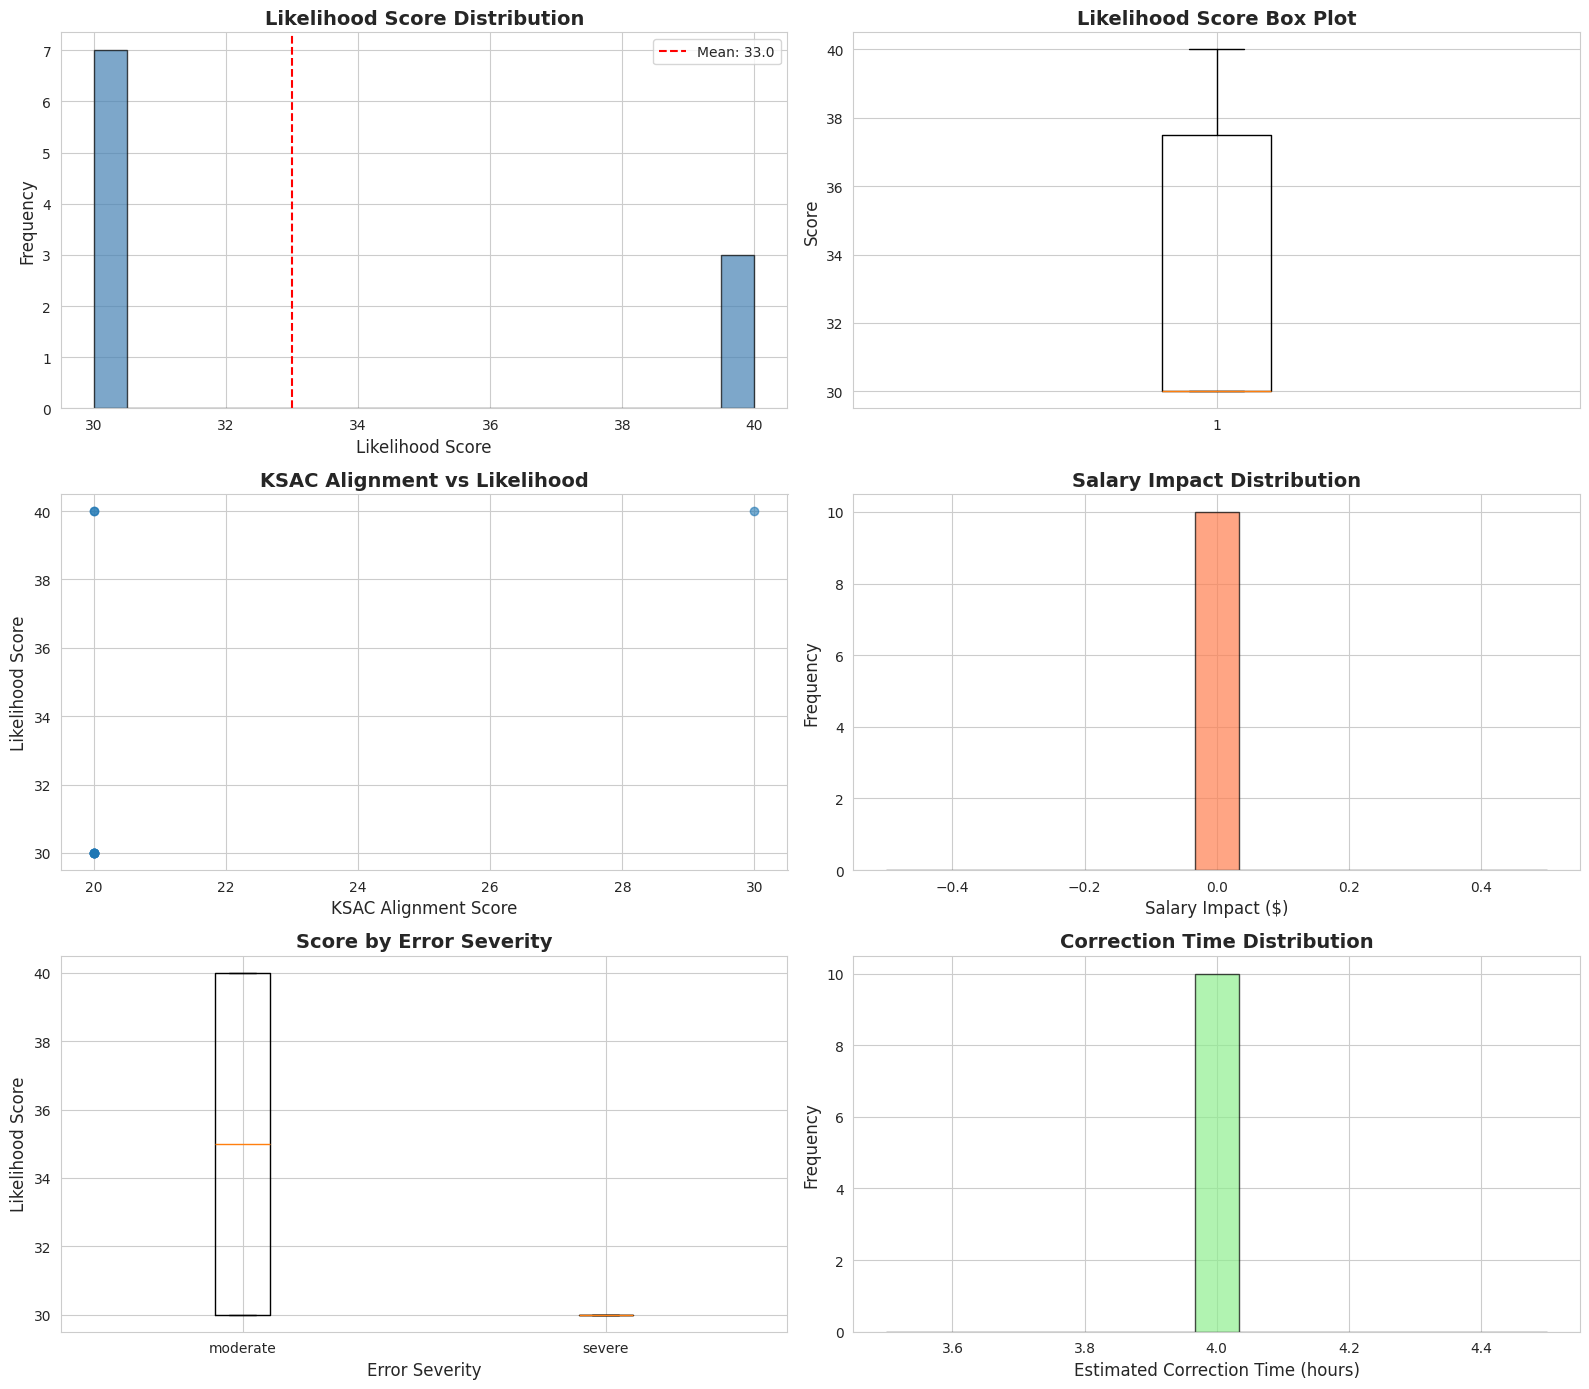

✓ Visualizations created and saved


In [38]:
# Visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Likelihood Score Distribution
axes[0, 0].hist(df_final['likelihood_score'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_final['likelihood_score'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df_final["likelihood_score"].mean():.1f}')
axes[0, 0].set_xlabel('Likelihood Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Likelihood Score Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# 2. Score Box Plot
axes[0, 1].boxplot(df_final['likelihood_score'].dropna())
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_title('Likelihood Score Box Plot', fontsize=14, fontweight='bold')

# 3. KSAC Alignment vs Likelihood Score
axes[1, 0].scatter(df_final['ksac_alignment_score'], df_final['likelihood_score'], alpha=0.6)
axes[1, 0].set_xlabel('KSAC Alignment Score', fontsize=12)
axes[1, 0].set_ylabel('Likelihood Score', fontsize=12)
axes[1, 0].set_title('KSAC Alignment vs Likelihood', fontsize=14, fontweight='bold')

# 4. Salary Impact Distribution
axes[1, 1].hist(df_final['salary_impact'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Salary Impact ($)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Salary Impact Distribution', fontsize=14, fontweight='bold')

# 5. Error Severity by Score
if 'error_severity' in df_final.columns:
    severity_order = ['none', 'minor', 'moderate', 'severe']
    severity_data = [df_final[df_final['error_severity'] == s]['likelihood_score'].dropna()
                     for s in severity_order if s in df_final['error_severity'].values]
    axes[2, 0].boxplot(severity_data, labels=[s for s in severity_order if s in df_final['error_severity'].values])
    axes[2, 0].set_xlabel('Error Severity', fontsize=12)
    axes[2, 0].set_ylabel('Likelihood Score', fontsize=12)
    axes[2, 0].set_title('Score by Error Severity', fontsize=14, fontweight='bold')

# 6. Correction Time Distribution
axes[2, 1].hist(df_final['estimated_correction_hours'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2, 1].set_xlabel('Estimated Correction Time (hours)', fontsize=12)
axes[2, 1].set_ylabel('Frequency', fontsize=12)
axes[2, 1].set_title('Correction Time Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/mnps_comprehensive_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations created and saved")

## 11. Detailed Failure Analysis

In [39]:
# Identify problematic cases
threshold = 70  # Scores below this are problematic
problematic_cases = df_final[df_final['likelihood_score'] < threshold].copy()

print(f"Problematic Cases (score < {threshold}): {len(problematic_cases)}")
print(f"Percentage: {len(problematic_cases)/len(df_final)*100:.1f}%\n")

if len(problematic_cases) > 0:
    print("\n=== TOP 5 MOST PROBLEMATIC CLASSIFICATIONS ===")
    print()

    for idx, row in problematic_cases.nsmallest(5, 'likelihood_score').iterrows():
        print(f"\nCase #{idx + 1}")
        print(f"Job Title: {row.get('job_title', row.get('Job_Title', 'N/A'))}")
        print(f"AI Classification: {row.get('ai_role', row.get('AI_Role', 'N/A'))}")
        print(f"Human Classification: {row.get('human_role', row.get('Human_Role', 'N/A'))}")
        print(f"Likelihood Score: {row['likelihood_score']:.0f}")
        print(f"Error Severity: {row.get('error_severity', 'N/A')}")
        print(f"Salary Impact: ${row.get('salary_impact', 0):,.0f}")
        print(f"Key Issues: {row.get('key_issues', 'N/A')}")
        print("-" * 80)

# Save problematic cases
if len(problematic_cases) > 0:
    problematic_file = f"{CONFIG['output_dir']}/problematic_classifications.csv"
    problematic_cases.to_csv(problematic_file, index=False)
    print(f"\n✓ Problematic cases saved to {problematic_file}")

Problematic Cases (score < 70): 10
Percentage: 16.4%


=== TOP 5 MOST PROBLEMATIC CLASSIFICATIONS ===


Case #1.0
Job Title: N/A
AI Classification: N/A
Human Classification: N/A
Likelihood Score: 30
Error Severity: moderate
Salary Impact: $0
Key Issues: ['Lack of AI classification details', 'Insufficient context for evaluation', 'Inability to assess KSAC alignment and justification quality']
--------------------------------------------------------------------------------

Case #3.0
Job Title: N/A
AI Classification: N/A
Human Classification: N/A
Likelihood Score: 30
Error Severity: severe
Salary Impact: $0
Key Issues: ['No assigned role was provided by the AI system.', 'Insufficient information to assess KSAC alignment.', 'Lack of justification for the classification decision.']
--------------------------------------------------------------------------------

Case #4.0
Job Title: N/A
AI Classification: N/A
Human Classification: N/A
Likelihood Score: 30
Error Severity: severe
Salary Impa

In [40]:
def generate_failure_summary(problematic_df: pd.DataFrame) -> str:
    """Generate comprehensive failure mode analysis using LLM."""

    if len(problematic_df) == 0:
        return "No problematic cases identified. System performing well."

    # Compile cases
    cases_text = "\n\n".join([
        f"""Case {idx+1}:
- AI Classification: {row.get('ai_role', 'N/A')}
- Correct Role: {row.get('human_role', 'N/A')}
- Score: {row['likelihood_score']:.0f}
- Key Issues: {row.get('key_issues', 'N/A')}
- Reasoning: {row.get('reasoning', 'N/A')[:200]}"""
        for idx, row in problematic_df.head(10).iterrows()
    ])

    summary_prompt = f"""Analyze the following problematic job classification cases and provide:

{cases_text}

1. Common failure patterns (what types of errors occur most frequently?)
2. Root causes (why is the AI making these mistakes?)
3. Specific recommendations for improving the classification system
4. Training data gaps that may need to be addressed

Provide a concise summary (300-400 words).
"""

    messages = [
        {"role": "system", "content": "You are an expert at analyzing AI system failures and providing actionable recommendations."},
        {"role": "user", "content": summary_prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1000,
            temperature=0.3,
            do_sample=True
        )

    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "assistant" in summary:
        summary = summary.split("assistant")[-1].strip()

    return summary

# Generate analysis
if len(problematic_cases) > 0:
    print("\nGenerating comprehensive failure analysis...\n")
    failure_analysis = generate_failure_summary(problematic_cases)

    print("=" * 80)
    print("COMPREHENSIVE FAILURE MODE ANALYSIS")
    print("=" * 80)
    print(failure_analysis)
    print("=" * 80)

    # Save analysis
    with open(f"{CONFIG['output_dir']}/failure_mode_analysis.txt", 'w') as f:
        f.write(failure_analysis)

    print(f"\n✓ Analysis saved to {CONFIG['output_dir']}/failure_mode_analysis.txt")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Generating comprehensive failure analysis...

COMPREHENSIVE FAILURE MODE ANALYSIS
**Common Failure Patterns:**

The most frequent errors in the AI classification system are:

1. **Lack of provided information**: The AI fails to provide any details about the assigned role or justification, making it impossible to evaluate its accuracy.
2. **Insufficient context**: The AI does not provide enough information to assess the job description, reference roles, or justification, leading to poor evaluation.
3. **Unclear justification**: The AI's decision-making process is unclear, making it challenging to understand the reasoning behind the assigned role.

**Root Causes:**

The root causes of these errors are:

1. **Inadequate training data**: The AI may not have been trained on sufficient or diverse data, leading to poor performance on unseen job descriptions.
2. **Lack of transparency in AI decision-making**: The AI's decision-making process is not transparent, making it difficult to understa

## 12. Final Export & Report

In [41]:
# Create comprehensive report
report = f"""# MNPS Job Classification Likelihood Scoring Report
Generated: {pd.Timestamp.now()}

## System Configuration
- Model: {CONFIG['model_name']}
- Total Evaluations: {len(df_final)}
- Batch Size: {CONFIG['batch_size']}
- KSAC Roles Indexed: {num_indexed}

## Performance Metrics

### Likelihood Scores
- Mean: {df_final['likelihood_score'].mean():.2f}
- Median: {df_final['likelihood_score'].median():.2f}
- Std Dev: {df_final['likelihood_score'].std():.2f}
- Range: {df_final['likelihood_score'].min():.0f} - {df_final['likelihood_score'].max():.0f}

### Score Distribution
- Excellent (90-100): {len(df_final[df_final['likelihood_score'] >= 90])}
- Good (75-89): {len(df_final[(df_final['likelihood_score'] >= 75) & (df_final['likelihood_score'] < 90)])}
- Acceptable (60-74): {len(df_final[(df_final['likelihood_score'] >= 60) & (df_final['likelihood_score'] < 75)])}
- Problematic (<60): {len(df_final[df_final['likelihood_score'] < 60])}

### Component Scores
- KSAC Alignment (avg): {df_final['ksac_alignment_score'].mean():.2f}
- Justification Quality (avg): {df_final['justification_quality_score'].mean():.2f}

### Impact Metrics
- Average Salary Impact: ${df_final['salary_impact'].mean():,.0f}
- Average Correction Time: {df_final['estimated_correction_hours'].mean():.1f} hours
- Total Estimated Correction Cost: {len(df_final) * df_final['estimated_correction_hours'].mean():.0f} hours

### Error Analysis
- Problematic Cases: {len(problematic_cases)} ({len(problematic_cases)/len(df_final)*100:.1f}%)

## Generated Files
1. mnps_likelihood_scores_detailed.csv - Full results with all metrics
2. problematic_classifications.csv - Cases requiring review
3. mnps_comprehensive_analysis.png - Visualization dashboard
4. failure_mode_analysis.txt - Detailed failure patterns

## Recommendations
1. Review all cases with scores < 70 for immediate correction
2. Analyze common failure patterns identified in failure mode analysis
3. Consider retraining model on problematic classification types
4. Implement active learning for borderline cases (scores 60-75)
5. Update KSAC definitions for roles with high error rates
"""

with open(f"{CONFIG['output_dir']}/FINAL_REPORT.md", 'w') as f:
    f.write(report)

print(report)
print(f"\n✓ Full report saved to {CONFIG['output_dir']}/FINAL_REPORT.md")

# MNPS Job Classification Likelihood Scoring Report
Generated: 2025-12-09 20:45:51.119289

## System Configuration
- Model: meta-llama/Meta-Llama-3.1-70B-Instruct
- Total Evaluations: 61
- Batch Size: 50
- KSAC Roles Indexed: 63

## Performance Metrics

### Likelihood Scores
- Mean: 33.00
- Median: 30.00
- Std Dev: 4.83
- Range: 30 - 40

### Score Distribution
- Excellent (90-100): 0
- Good (75-89): 0
- Acceptable (60-74): 0
- Problematic (<60): 10

### Component Scores
- KSAC Alignment (avg): 21.00
- Justification Quality (avg): 24.00

### Impact Metrics
- Average Salary Impact: $0
- Average Correction Time: 4.0 hours
- Total Estimated Correction Cost: 244 hours

### Error Analysis
- Problematic Cases: 10 (16.4%)

## Generated Files
1. mnps_likelihood_scores_detailed.csv - Full results with all metrics
2. problematic_classifications.csv - Cases requiring review
3. mnps_comprehensive_analysis.png - Visualization dashboard
4. failure_mode_analysis.txt - Detailed failure patterns

## Rec

In [42]:
# Download all results (in Colab)
import shutil

# Create zip of all results
shutil.make_archive('mnps_results', 'zip', CONFIG['output_dir'])
files.download('mnps_results.zip')

print("✓ All processing complete!")
print(f"\nResults directory: {CONFIG['output_dir']}")
print("\nGenerated files:")
for file in sorted(Path(CONFIG['output_dir']).glob('*')):
    print(f"  - {file.name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All processing complete!

Results directory: ./mnps_results

Generated files:
  - FINAL_REPORT.md
  - failure_mode_analysis.txt
  - mnps_comprehensive_analysis.png
  - mnps_likelihood_scores_detailed.csv
  - problematic_classifications.csv
